# Metodologia Box Jenkins en ARMA

1. Estacionariedad → verificar (ADF) y transformar si hace falta (diferenciación, log...)
2. ACF/PACF → identificar p y q
3. Estimar el modelo con esos órdenes
3. Diagnosticar los residuos (Ljung-Box, ACF de residuos)

Estadístico ADF: -6.4381
p-valor:         0.0000
✅ Serie estacionaria → podemos aplicar ARMA directamente


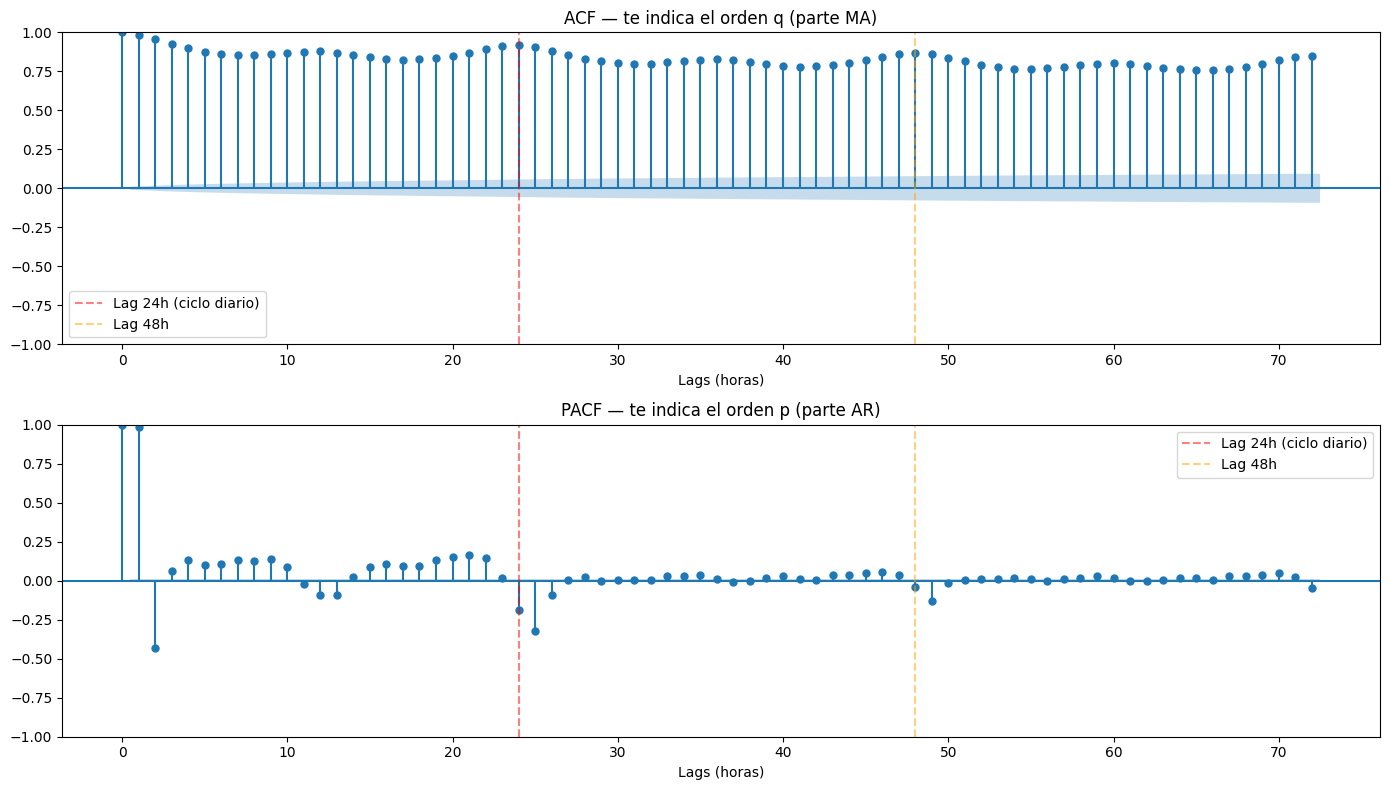

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ==============================
# 1. Cargar y preparar la serie (igual que antes)
# ==============================
df = pd.read_csv('limpiezaPrecio3_Omie2020_2024.csv', sep=";")
df['datetime'] = pd.to_datetime(df['datetime'])
#ordenar por fecha por si acaso
df.set_index('datetime', inplace=True)
df.sort_index(inplace=True) 

serie = df['price'].replace([np.inf, -np.inf], np.nan).dropna()
serie = serie.asfreq('h')

# ==============================
# 2. Verificar estacionariedad
# ==============================
test = adfuller(serie)

#test[0] es el estadístico ADF (cuanto mas negativo más estacionaria es la serie)
#test[1] es el p-valor (si es menor a 0.05, rechazamos la hipótesis nula de no estacionariedad)

print(f'Estadístico ADF: {test[0]:.4f}')
print(f'p-valor:         {test[1]:.4f}')

if test[1] <= 0.05:
    print("Serie estacionaria -> podemos aplicar ARMA directamente")
    serie_modelo = serie
else:
    print("No estacionaria -> diferenciamos una vez")

    serie_modelo = serie.diff().dropna()
    # Verificar de nuevo
    res2 = adfuller(serie_modelo)
    print(f'   ADF tras diferenciar: {res2[0]:.4f}, p-valor: {res2[1]:.4f}')

# ==============================
# 3. ACF y PACF para identificar p y q
# ==============================
# Usamos 72 lags (3 días) para ver los patrones diarios
# También se puede probar con lags=168 (ciclo semanal)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(serie_modelo, lags=72, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF — te indica el orden q (parte MA)')
axes[0].set_xlabel('Lags (horas)')
axes[0].axvline(x=24, color='red', linestyle='--', alpha=0.5, label='Lag 24h (ciclo diario)')
axes[0].axvline(x=48, color='orange', linestyle='--', alpha=0.5, label='Lag 48h')
axes[0].legend()

plot_pacf(serie_modelo, lags=72, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('PACF — te indica el orden p (parte AR)')
axes[1].set_xlabel('Lags (horas)')
axes[1].axvline(x=24, color='red', linestyle='--', alpha=0.5, label='Lag 24h (ciclo diario)')
axes[1].axvline(x=48, color='orange', linestyle='--', alpha=0.5, label='Lag 48h')
axes[1].legend()

plt.tight_layout()
plt.savefig('box_jenkins_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

## Como interpretar resultados:

PatrónDiagnósticoPACF corta bruscamente en lag p, ACF decae gradual→ Modelo AR(p)
ACF corta bruscamente en lag q, PACF decae gradual→ Modelo MA(q)
Ambas decaen gradualmente→ Modelo ARMA(p,q) mixto
Picos significativos en lag 24, 48...→ Hay estacionalidad (aviso para SARIMA)